In [ ]:
import os
import re

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

In [4]:
dataset_File_path = r"data/augmented_dataset.csv"

df = pd.read_csv(dataset_File_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5411, 8)


,_id,vendorId,itemName,itemDescription,accountId,accountName,itemTotalAmount,is_synthetic
0,{'$oid': '69606546de1e297ec29890f2'},6m656Er7lbi8RYz2ny1J,1225 Business 2Gbps - monthly subscription fee,1225 Business 2Gbps - monthly subscription fee,88AW5nmkLvMe1GthZ6FL,619206 Telephone & Internet,888.00,False
1,{'$oid': '695b5304d09b4ceb96e5288e'},VtxikZ7HI6Jwqueemjch,1225-0227 media monitoring,1225-0227 media monitoring,sWG9pai5DiLXaKs6s86G,134004 Prepaid Subscription,17765.00,False
2,{'$oid': '69800f97e85d532c0db71c7e'},jdmr9pJ0WHqso4Wh3hCa,0226 Branch,0226 Branch,C0SB5vR0gCikdKjmT8Ep,611202 Online Subscription/Tool,7083.34,False
3,{'$oid': '6981a56e83888e7f4589cf09'},A17M26ij1P8uGEnRFtP0,0126 GAM (SG),0126 GAM (SG),IbDOq9NsCcO8rSg7Uk1y,511301 Display COGS,2609.11,False
4,{'$oid': '6981a56e83888e7f4589cf09'},A17M26ij1P8uGEnRFtP0,0126 GAM (Chotot & Mudah),0126 GAM (Chotot & Mudah),w5hjK0IooxdDp9Feeeuy,132098 IC Clearing account - Paid on Behalf,1243.22,False


## 1. Exploratory Data Analysis

In [5]:
print("=== DTYPES ===")
print(df.dtypes)
print("\n=== NULL COUNTS ===")
print(df.isna().sum())

=== DTYPES ===
_id                 object
vendorId            object
itemName            object
itemDescription     object
accountId           object
accountName         object
itemTotalAmount    float64
is_synthetic          bool
dtype: object

=== NULL COUNTS ===
_id                 0
vendorId            0
itemName            0
itemDescription    31
accountId           0
accountName         0
itemTotalAmount     0
is_synthetic        0
dtype: int64


In [6]:
missing_item_desc = df[
    df['itemDescription'].isna() |
    df['itemDescription'].astype(str).str.strip().eq('')
]
print(f"Missing itemDescription rows: {len(missing_item_desc)}")
print(missing_item_desc[['itemName', 'itemDescription', 'accountName', 'itemTotalAmount']].to_string(index=False))

Missing itemDescription rows: 31
                                                                                                                       itemName itemDescription                     accountName  itemTotalAmount
                                                                                                Carousell- Plush w Foldable Bag             NaN                 612005 Giveaway           650.00
                                                                                                             0825 Vonage SMS SG             NaN 611202 Online Subscription/Tool             6.67
                                                                                                            0825 DHL Deliveries             NaN      619518 Courier and postage            51.64
                                                                                                            0825 DHL Deliveries             NaN      619518 Courier and postage            62.34
  

#### Remark: Only 31 rows (0.63%) have missing `itemDescription`. These will be filled using `itemName_cleaned` since the fields are 83% identical.

In [7]:
real_for_eda = df.loc[~df["is_synthetic"]].copy()
print(real_for_eda.groupby("accountName").size().sort_values(ascending=True))

accountName
131002 Staff Advance                        1
617302 Online Portal Expense / Events       1
617213 Marketing Research                   1
612039 Marketing Research                   1
612023 Print Ads                            1
                                         ... 
614123 Employee On Record                 175
134001 Prepaid Operating Expense          193
619203 Supplies/Expenses                  225
132098 IC Clearing account                706
611202 Online Subscription/Tool          1179
Length: 103, dtype: int64


#### Class Imbalance Observation

Class balance is assessed using **real transactions only**.  
Classes with fewer than five real examples are not eligible for automated evaluation because they cannot support a stable train / validation / test split. They should be routed to human review until more labelled history is available.

In [ ]:
marketing_rows = df[df['accountName'].str.contains('Marketing Research', na=False)].copy()
print(marketing_rows[['accountName', 'accountId', 'itemName']].to_string(index=False))

              accountName            accountId                                                   itemName
612039 Marketing Research lXfE1brSF0STqngL58cZ            0125 SG Market Research (brand tracker) credits
617213 Marketing Research lXfE1brSF0STqngL58cZ                                 0324 Brand survey research
612039 Marketing Research            SYNTH_ACC 0226 SG Market Research (Survey Tool Subscription) credits
612039 Marketing Research            SYNTH_ACC                                  1234 AdTech Research Firm
612039 Marketing Research            SYNTH_ACC            0125 SG Market Research (Brand Tracker) credits
612039 Marketing Research            SYNTH_ACC                                1456 Market Research Agency
612039 Marketing Research            SYNTH_ACC                           0987 Social Media Listening Tool
612039 Marketing Research            SYNTH_ACC            0125 SG Market Research (brand tracker) credits
612039 Marketing Research            SYNTH_ACC

In [ ]:
vendor_accounts = real_for_eda.groupby("vendorId")["accountName"].nunique()
deterministic_vendors = vendor_accounts[vendor_accounts == 1].index
covered_rows = real_for_eda[real_for_eda["vendorId"].isin(deterministic_vendors)]

print("Accounts per vendor distribution:")
print(vendor_accounts.value_counts().sort_index())
print(f"\nDeterministic vendors: {len(deterministic_vendors)}")
print(
    f"Real rows covered: {len(covered_rows)} "
    f"({len(covered_rows) / len(real_for_eda):.1%})"
)
print(
    "\nVendor history will be used only as a train-only fallback rule. "
    "It is never computed from validation or test data."
)

Accounts per vendor distribution:
accountName
1     211
2      71
3      27
4      12
5       7
6       5
7       2
9       1
19      1
Name: count, dtype: int64

Deterministic vendors: 211
Real rows covered: 1537 (31.4%)

Vendor history will be used only as a train-only fallback rule. It is never computed from validation or test data.


## 2. Data Preprocessing

In [ ]:
df['itemName'] = df['itemName'].str.replace('\n', ',', regex=False)
df['itemName'] = df['itemName'].str.replace('\t', ' ', regex=False)

### 2.1 Strip Noisy Date Prefix from Text Fields

~88% of `itemName` entries begin with a billing period prefix such as `0126`, `1225`, `1225-0227`.  
These are billing months — pure metadata noise with no account-predictive signal.

Examples:
- `"0126 Google Cloud"` → `"Google Cloud"`
- `"1225-0227 Telum Media Sub"` → `"Telum Media Sub"`
- `"0126 - Content Creation Retainer"` → `"Content Creation Retainer"`

In [11]:
def strip_date(text: str) -> str:
    """Remove leading MMYY or MMYY-MMYY billing date prefixes."""
    if pd.isna(text):
        return ''
    text = re.sub(r'^\d{4}(-\d{4})?\s*[-\u2013]?\s*', '', str(text)).strip()
    return text

df['itemName_cleaned'] = df['itemName'].apply(strip_date)
df['itemDescription']  = df['itemDescription'].apply(strip_date)

print("Before:", df['itemName'].iloc[1])
print("After :", df['itemName_cleaned'].iloc[1])

Before: 1225-0227 media monitoring
After : media monitoring


In [ ]:
same  = (df['itemName_cleaned'].fillna('') == df['itemDescription'].fillna('')).sum()
total = len(df)
print(f"Identical itemName and itemDescription: {same}/{total} = {same/total*100:.1f}%")

Identical itemName and itemDescription: 4194/5411 = 77.5%


In [ ]:
df['itemDescription']  = df['itemDescription'].fillna(df['itemName_cleaned'])
df['merged_iName_iDesc'] = (
    df['itemName_cleaned'].fillna('') + ' ' +
    df['itemDescription'].fillna('')
).str.strip()

print("Sample merged text:")
print(df['merged_iName_iDesc'].head(5).to_string())

Sample merged text:
0    Business 2Gbps - monthly subscription fee Busi...
1                    media monitoring media monitoring
2                                        Branch Branch
3                                    GAM (SG) GAM (SG)
4            GAM (Chotot & Mudah) GAM (Chotot & Mudah)


## 3. Feature Engineering

### 3.1 Dropping Columns

**`accountId`** — dropped for two reasons:
1. **Target Leakage**: directly maps to `accountName` (97 unique IDs → 103 unique names). Including it would mean the model is given the answer.
2. **Unavailable at Inference**: new bills don't have an `accountId` yet — that's what we predict.

**`_id`** — dropped because:
1. **No signal**: random MongoDB ObjectID, the model cannot learn from it.
2. **Unavailable at Inference**: new expenses get new IDs never seen in training.

In [14]:
df.drop(columns=['accountId', '_id'], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['vendorId', 'itemName', 'itemDescription', 'accountName', 'itemTotalAmount', 'is_synthetic', 'itemName_cleaned', 'merged_iName_iDesc']


### 3.2 Text Length Features

Longer descriptions correlate with account type:
- **Short (1–2 words):** SaaS tools → `611202 Online Subscription`
- **Verbose:** HR/legal billing → `617104 Temporary Staff`, `617205 Consultancy`

These are weak but free signals — help LightGBM break prediction ties.

In [15]:
df['text_len'] = df['merged_iName_iDesc'].str.len()
df['word_len']  = df['merged_iName_iDesc'].str.split().str.len()

### 3.3 `itemTotalAmount` — Keep with Log Transform

Raw boxplot appears flat due to extreme outliers ($161M).  
After `log1p` transform, clear per-category spread is visible:

| Account | Approx. median |
|---|---|
| `619203 Supplies/Expenses` | $140 |
| `611202 Online Subscription` | $279 |
| `617205 Consultancy Expense` | $4,583 |

**Decision:** Apply `log1p` and keep the feature. LightGBM (tree-based) is robust to remaining outliers.

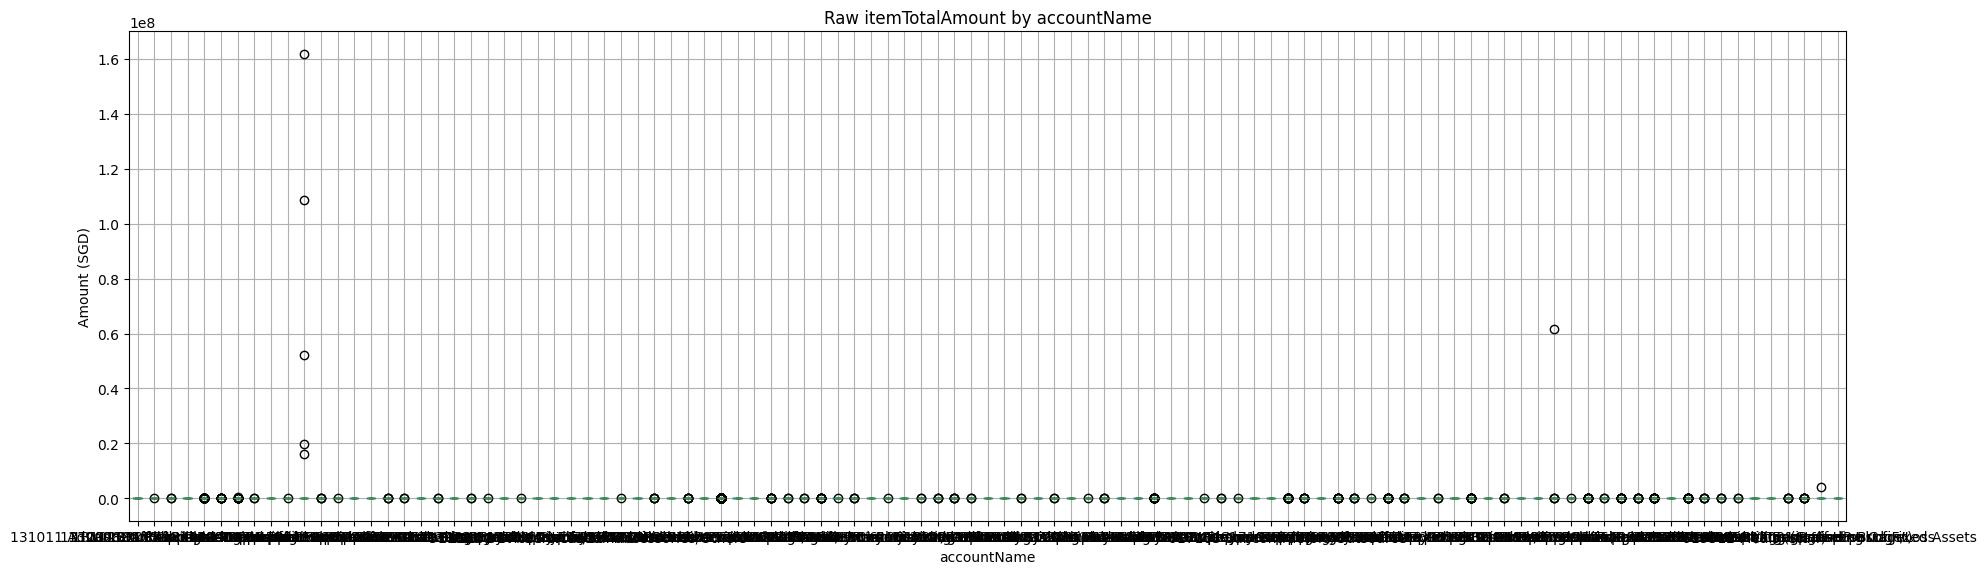

In [ ]:
df.boxplot(column='itemTotalAmount', by='accountName', figsize=(20, 6))
plt.suptitle('')
plt.title('Raw itemTotalAmount by accountName')
plt.xlabel('accountName')
plt.ylabel('Amount (SGD)')
plt.tight_layout()
plt.show()

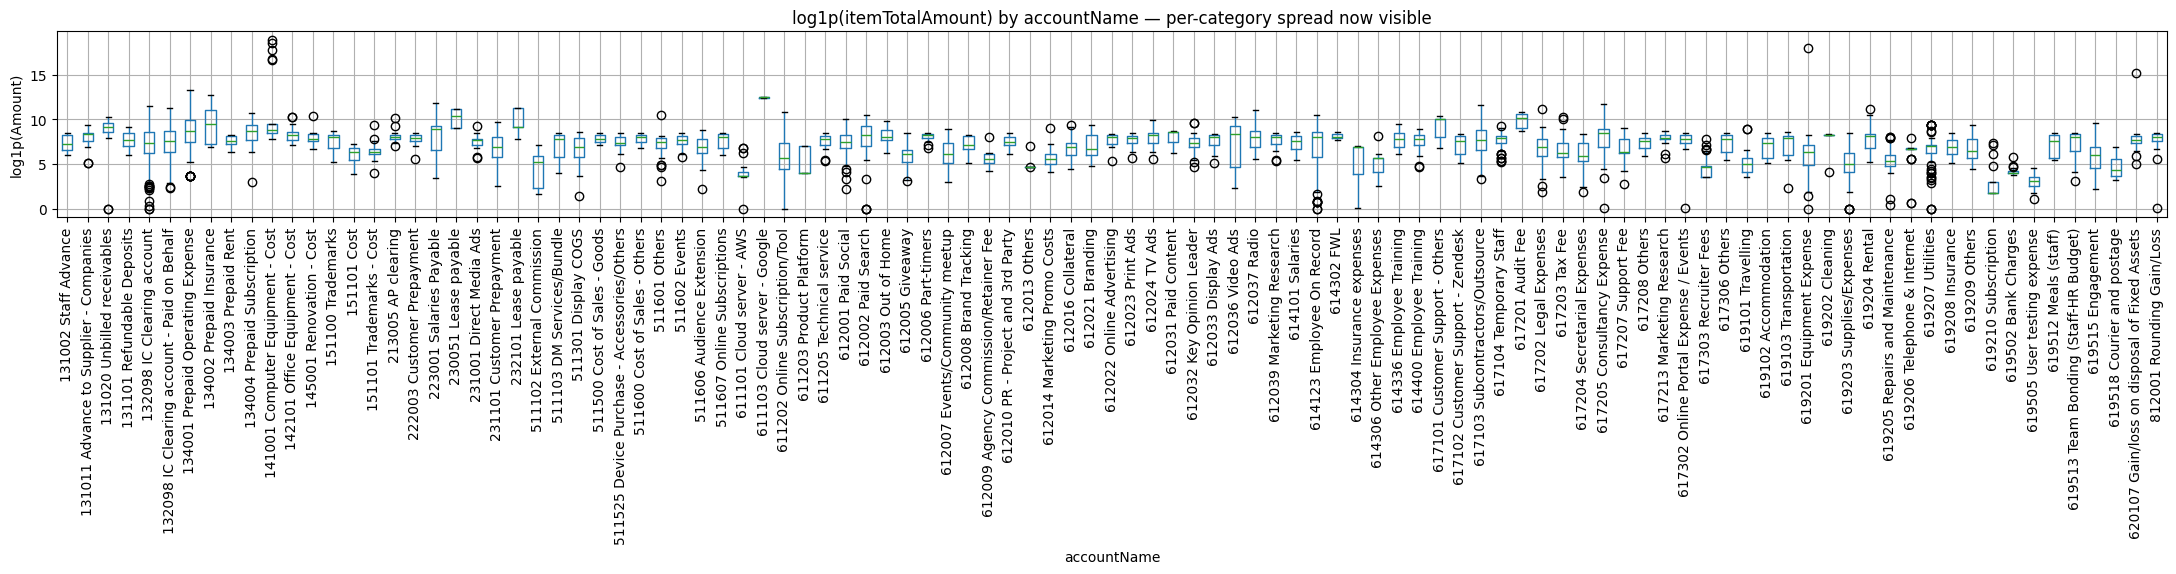

In [ ]:
df['log_amount'] = np.log1p(df['itemTotalAmount'].clip(lower=0))

df.boxplot(column='log_amount', by='accountName', figsize=(22, 6), rot=90)
plt.suptitle('')
plt.title('log1p(itemTotalAmount) by accountName — per-category spread now visible')
plt.xlabel('accountName')
plt.ylabel('log1p(Amount)')
plt.tight_layout()
plt.show()

## 4. Model Preparation

### 4.1 Train, Validation, and Test Policy

- Validation and final test sets contain **real transactions only**.
- Synthetic rows may be added to the training set only.
- Classes with fewer than five real examples are routed to review rather than used to claim automated-model performance.
- The final test set is not used to select model settings.

## 5. Reproducible Text Classification Pipeline

The classifier uses word-level TF–IDF features and a linear support-vector classifier. This is a suitable baseline for short, repetitive accounting descriptions with limited labelled data.

`vendorId` is represented as a categorical text token, never as an ordinal number. This avoids arbitrary numeric splits such as “vendor 40 is closer to vendor 41 than vendor 300”.

In [ ]:
MIN_REAL_SAMPLES_PER_CLASS = 5

df_real = df.loc[~df["is_synthetic"]].copy()
df_synth = df.loc[df["is_synthetic"]].copy()

real_class_counts = df_real["accountName"].value_counts()
eligible_classes = real_class_counts[
    real_class_counts >= MIN_REAL_SAMPLES_PER_CLASS
].index
review_only_classes = real_class_counts[
    real_class_counts < MIN_REAL_SAMPLES_PER_CLASS
].index

df_real = df_real[df_real["accountName"].isin(eligible_classes)].copy()
df_synth = df_synth[df_synth["accountName"].isin(eligible_classes)].copy()

train_real, remaining_real = train_test_split(
    df_real,
    test_size=0.40,
    stratify=df_real["accountName"],
    random_state=42,
)

valid_real, test_df = train_test_split(
    remaining_real,
    test_size=0.50,
    stratify=remaining_real["accountName"],
    random_state=42,
)

train_df = pd.concat([train_real, df_synth], ignore_index=True)

le = LabelEncoder().fit(train_real["accountName"])
y_train = le.transform(train_df["accountName"])
y_valid = le.transform(valid_real["accountName"])
y_test = le.transform(test_df["accountName"])

assert set(valid_real["accountName"]).issubset(set(le.classes_))
assert set(test_df["accountName"]).issubset(set(le.classes_))

print(f"Automated classes (>= {MIN_REAL_SAMPLES_PER_CLASS} real rows): {len(le.classes_)}")
print(f"Review-only classes: {len(review_only_classes)}")
print(f"Real training rows: {len(train_real)}")
print(f"Synthetic training rows: {len(df_synth)}")
print(f"Validation rows: {len(valid_real)}")
print(f"Final test rows: {len(test_df)}")

Automated classes (>= 5 real rows): 69
Review-only classes: 34
Real training rows: 2895
Synthetic training rows: 75
Validation rows: 965
Final test rows: 966


### 5.1 TF–IDF + LinearSVC Model Selection

Model settings are selected using the validation set only. The final test set remains untouched until the last cell.

In [19]:
def classifier_text(frame):
    return (
        frame["merged_iName_iDesc"].fillna("").str.lower()
        + " __vendor_" + frame["vendorId"].astype(str).str.lower()
    )

tfidf_dev = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
    strip_accents="unicode",
)

X_train_dev = tfidf_dev.fit_transform(classifier_text(train_df))
X_valid_dev = tfidf_dev.transform(classifier_text(valid_real))

candidate_results = []
for c_value in (0.5, 1.0, 2.0):
    candidate = LinearSVC(
        C=c_value,
        dual="auto",
        max_iter=3000,
        random_state=42,
    )
    candidate.fit(X_train_dev, y_train)
    valid_pred = candidate.predict(X_valid_dev)

    candidate_results.append(
        {
            "C": c_value,
            "validation_accuracy": accuracy_score(y_valid, valid_pred),
            "validation_macro_f1": f1_score(
                y_valid, valid_pred, average="macro", zero_division=0
            ),
        }
    )

tuning_results = pd.DataFrame(candidate_results).sort_values(
    ["validation_macro_f1", "validation_accuracy"],
    ascending=False,
).reset_index(drop=True)

best_c = float(tuning_results.loc[0, "C"])
print(tuning_results.to_string(index=False))
print(f"\nSelected C from validation only: {best_c}")

  C  validation_accuracy  validation_macro_f1
2.0             0.892228             0.847263
1.0             0.889119             0.846895
0.5             0.882902             0.831205

Selected C from validation only: 2.0


### 5.2 Final Model and Safe Vendor Fallback

A vendor prediction overrides the text model only when that vendor has at least three real training examples and all of them have the same account label. This mapping is built from training history only.

In [ ]:
final_train_df = pd.concat(
    [train_real, valid_real, df_synth],
    ignore_index=True,
)
y_final_train = le.transform(final_train_df["accountName"])

tfidf_final = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
    strip_accents="unicode",
)

X_final_train = tfidf_final.fit_transform(classifier_text(final_train_df))
X_final_test = tfidf_final.transform(classifier_text(test_df))

model_final = LinearSVC(
    C=best_c,
    dual="auto",
    max_iter=3000,
    random_state=42,
)
model_final.fit(X_final_train, y_final_train)


final_real_history = pd.concat([train_real, valid_real], ignore_index=True)
vendor_stats = final_real_history.groupby("vendorId")["accountName"].agg(
    count="size",
    labels="nunique",
    predicted_account=lambda values: values.mode().iat[0],
)

safe_vendor_map = vendor_stats[
    (vendor_stats["count"] >= 3)
    & (vendor_stats["labels"] == 1)
]["predicted_account"]

test_pred_labels = le.inverse_transform(model_final.predict(X_final_test))

vendor_override = test_df["vendorId"].map(safe_vendor_map)
vendor_mask = vendor_override.notna().to_numpy()
test_pred_labels[vendor_mask] = vendor_override.loc[vendor_mask].to_numpy()

test_accuracy = accuracy_score(test_df["accountName"], test_pred_labels)
test_macro_f1 = f1_score(
    test_df["accountName"],
    test_pred_labels,
    average="macro",
    zero_division=0,
)

print("FINAL TEST RESULTS")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Macro F1: {test_macro_f1:.4f}")
print(f"Safe vendor-rule coverage: {vendor_mask.mean():.1%}")
print()
print(
    classification_report(
        test_df["accountName"],
        test_pred_labels,
        zero_division=0,
    )
)

FINAL TEST RESULTS
Accuracy: 0.8892
Macro F1: 0.8464
Safe vendor-rule coverage: 33.9%

                                             precision    recall  f1-score   support

                131020 Unbilled receivables       1.00      1.00      1.00         5
                 132098 IC Clearing account       0.85      0.92      0.88       142
132098 IC Clearing account - Paid on Behalf       0.64      0.52      0.57        27
           134001 Prepaid Operating Expense       0.79      0.67      0.72        39
                   134002 Prepaid Insurance       1.00      0.33      0.50         3
                134004 Prepaid Subscription       0.50      0.25      0.33         4
           141001 Computer Equipment - Cost       1.00      0.86      0.92         7
             142101 Office Equipment - Cost       0.75      1.00      0.86         3
                                151101 Cost       0.67      0.67      0.67         3
                   151101 Trademarks - Cost       0.60      0.

In [23]:
X_real_train = tfidf_final.transform(classifier_text(final_real_history))
y_real_train = le.transform(final_real_history["accountName"])

train_pred = model_final.predict(X_real_train)

print(
    f" training accuracy: "
    f"{accuracy_score(y_real_train, train_pred):.4f}"
)

 training accuracy: 0.9705


In [22]:
print(f"Train–test gap: {accuracy_score(y_real_train, train_pred) - test_accuracy:.4f}")

Train–test gap: 0.0812


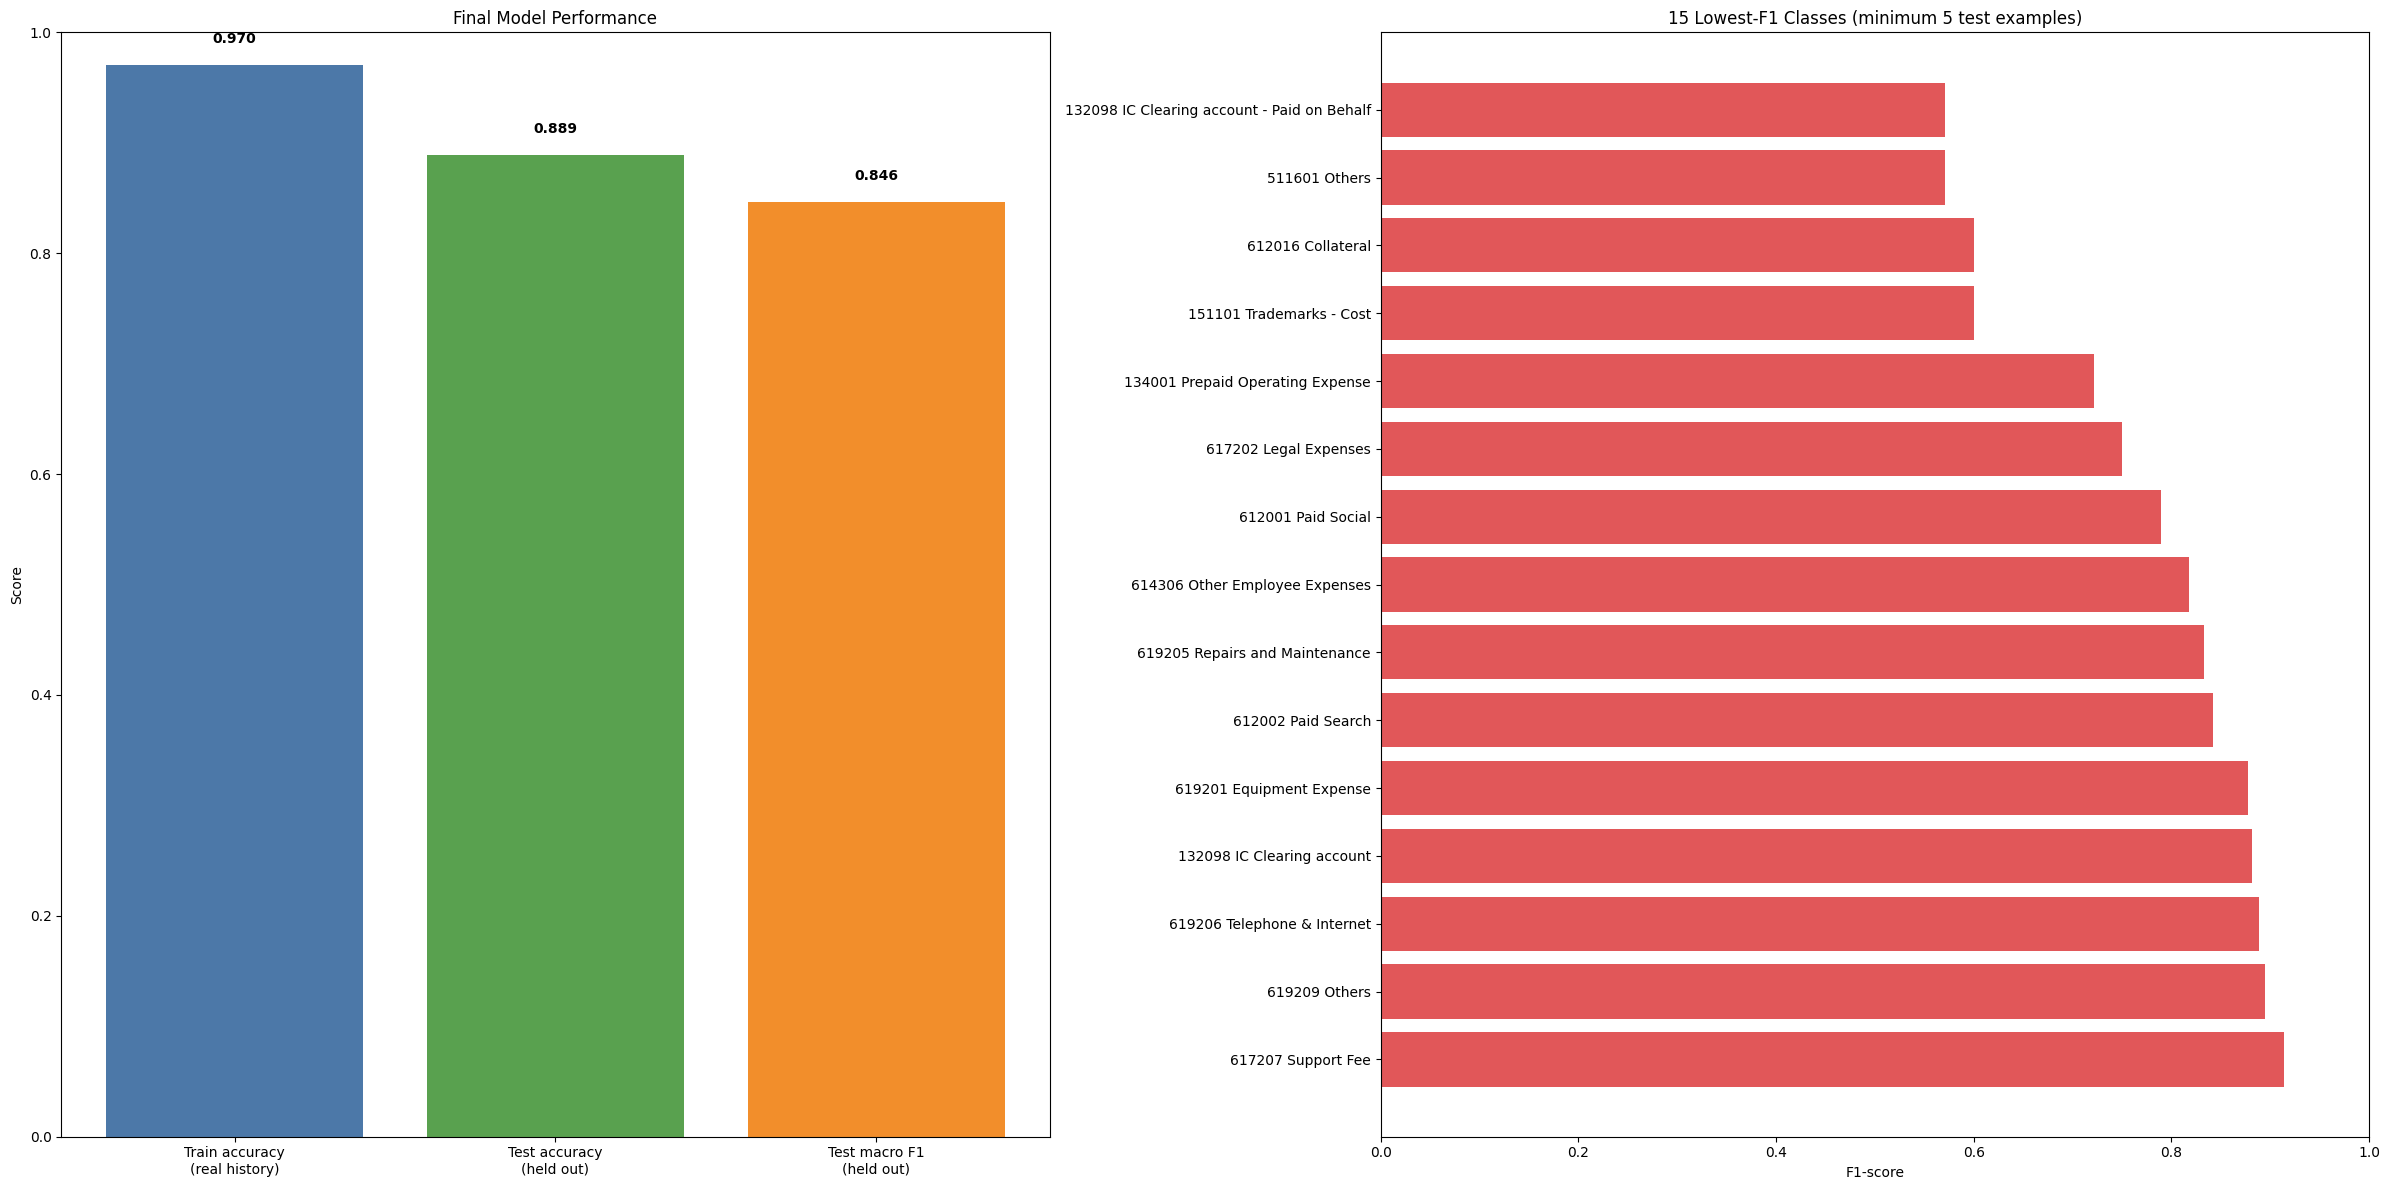

Safe vendor fallback coverage: 33.9%
Train–test gap: 0.0812


In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)


def apply_vendor_fallback(frame, predicted_labels):
    final_labels = np.asarray(predicted_labels, dtype=object).copy()
    vendor_override = frame["vendorId"].map(safe_vendor_map)
    override_mask = vendor_override.notna().to_numpy()
    final_labels[override_mask] = vendor_override.loc[override_mask].to_numpy()
    return final_labels, override_mask


X_history = tfidf_final.transform(classifier_text(final_real_history))
history_base_pred = le.inverse_transform(model_final.predict(X_history))
history_pred, _ = apply_vendor_fallback(final_real_history, history_base_pred)


test_base_pred = le.inverse_transform(model_final.predict(X_final_test))
test_pred, test_vendor_mask = apply_vendor_fallback(test_df, test_base_pred)

train_accuracy = accuracy_score(final_real_history["accountName"], history_pred)
test_accuracy_chart = accuracy_score(test_df["accountName"], test_pred)
test_macro_f1_chart = f1_score(
    test_df["accountName"],
    test_pred,
    average="macro",
    zero_division=0,
)


report_df = pd.DataFrame(
    classification_report(
        test_df["accountName"],
        test_pred,
        output_dict=True,
        zero_division=0,
    )
).T

class_metrics = report_df.drop(
    index=["accuracy", "macro avg", "weighted avg"],
    errors="ignore",
)
class_metrics = class_metrics[class_metrics["support"] >= 5]
lowest_f1 = class_metrics.sort_values("f1-score").head(15)


fig, axes = plt.subplots(1, 2, figsize=(24, 12))

metrics = {
    "Train accuracy\n(real history)": train_accuracy,
    "Test accuracy\n(held out)": test_accuracy_chart,
    "Test macro F1\n(held out)": test_macro_f1_chart,
}

bars = axes[0].bar(
    metrics.keys(),
    metrics.values(),
    color=["#4C78A8", "#59A14F", "#F28E2B"],
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_title("Final Model Performance")

for bar, value in zip(bars, metrics.values()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold",
    )

axes[1].barh(
    lowest_f1.index,
    lowest_f1["f1-score"],
    color="#E15759",
)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("F1-score")
axes[1].set_title("15 Lowest-F1 Classes (minimum 5 test examples)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Safe vendor fallback coverage: {test_vendor_mask.mean():.1%}")
print(f"Train–test gap: {train_accuracy - test_accuracy_chart:.4f}")

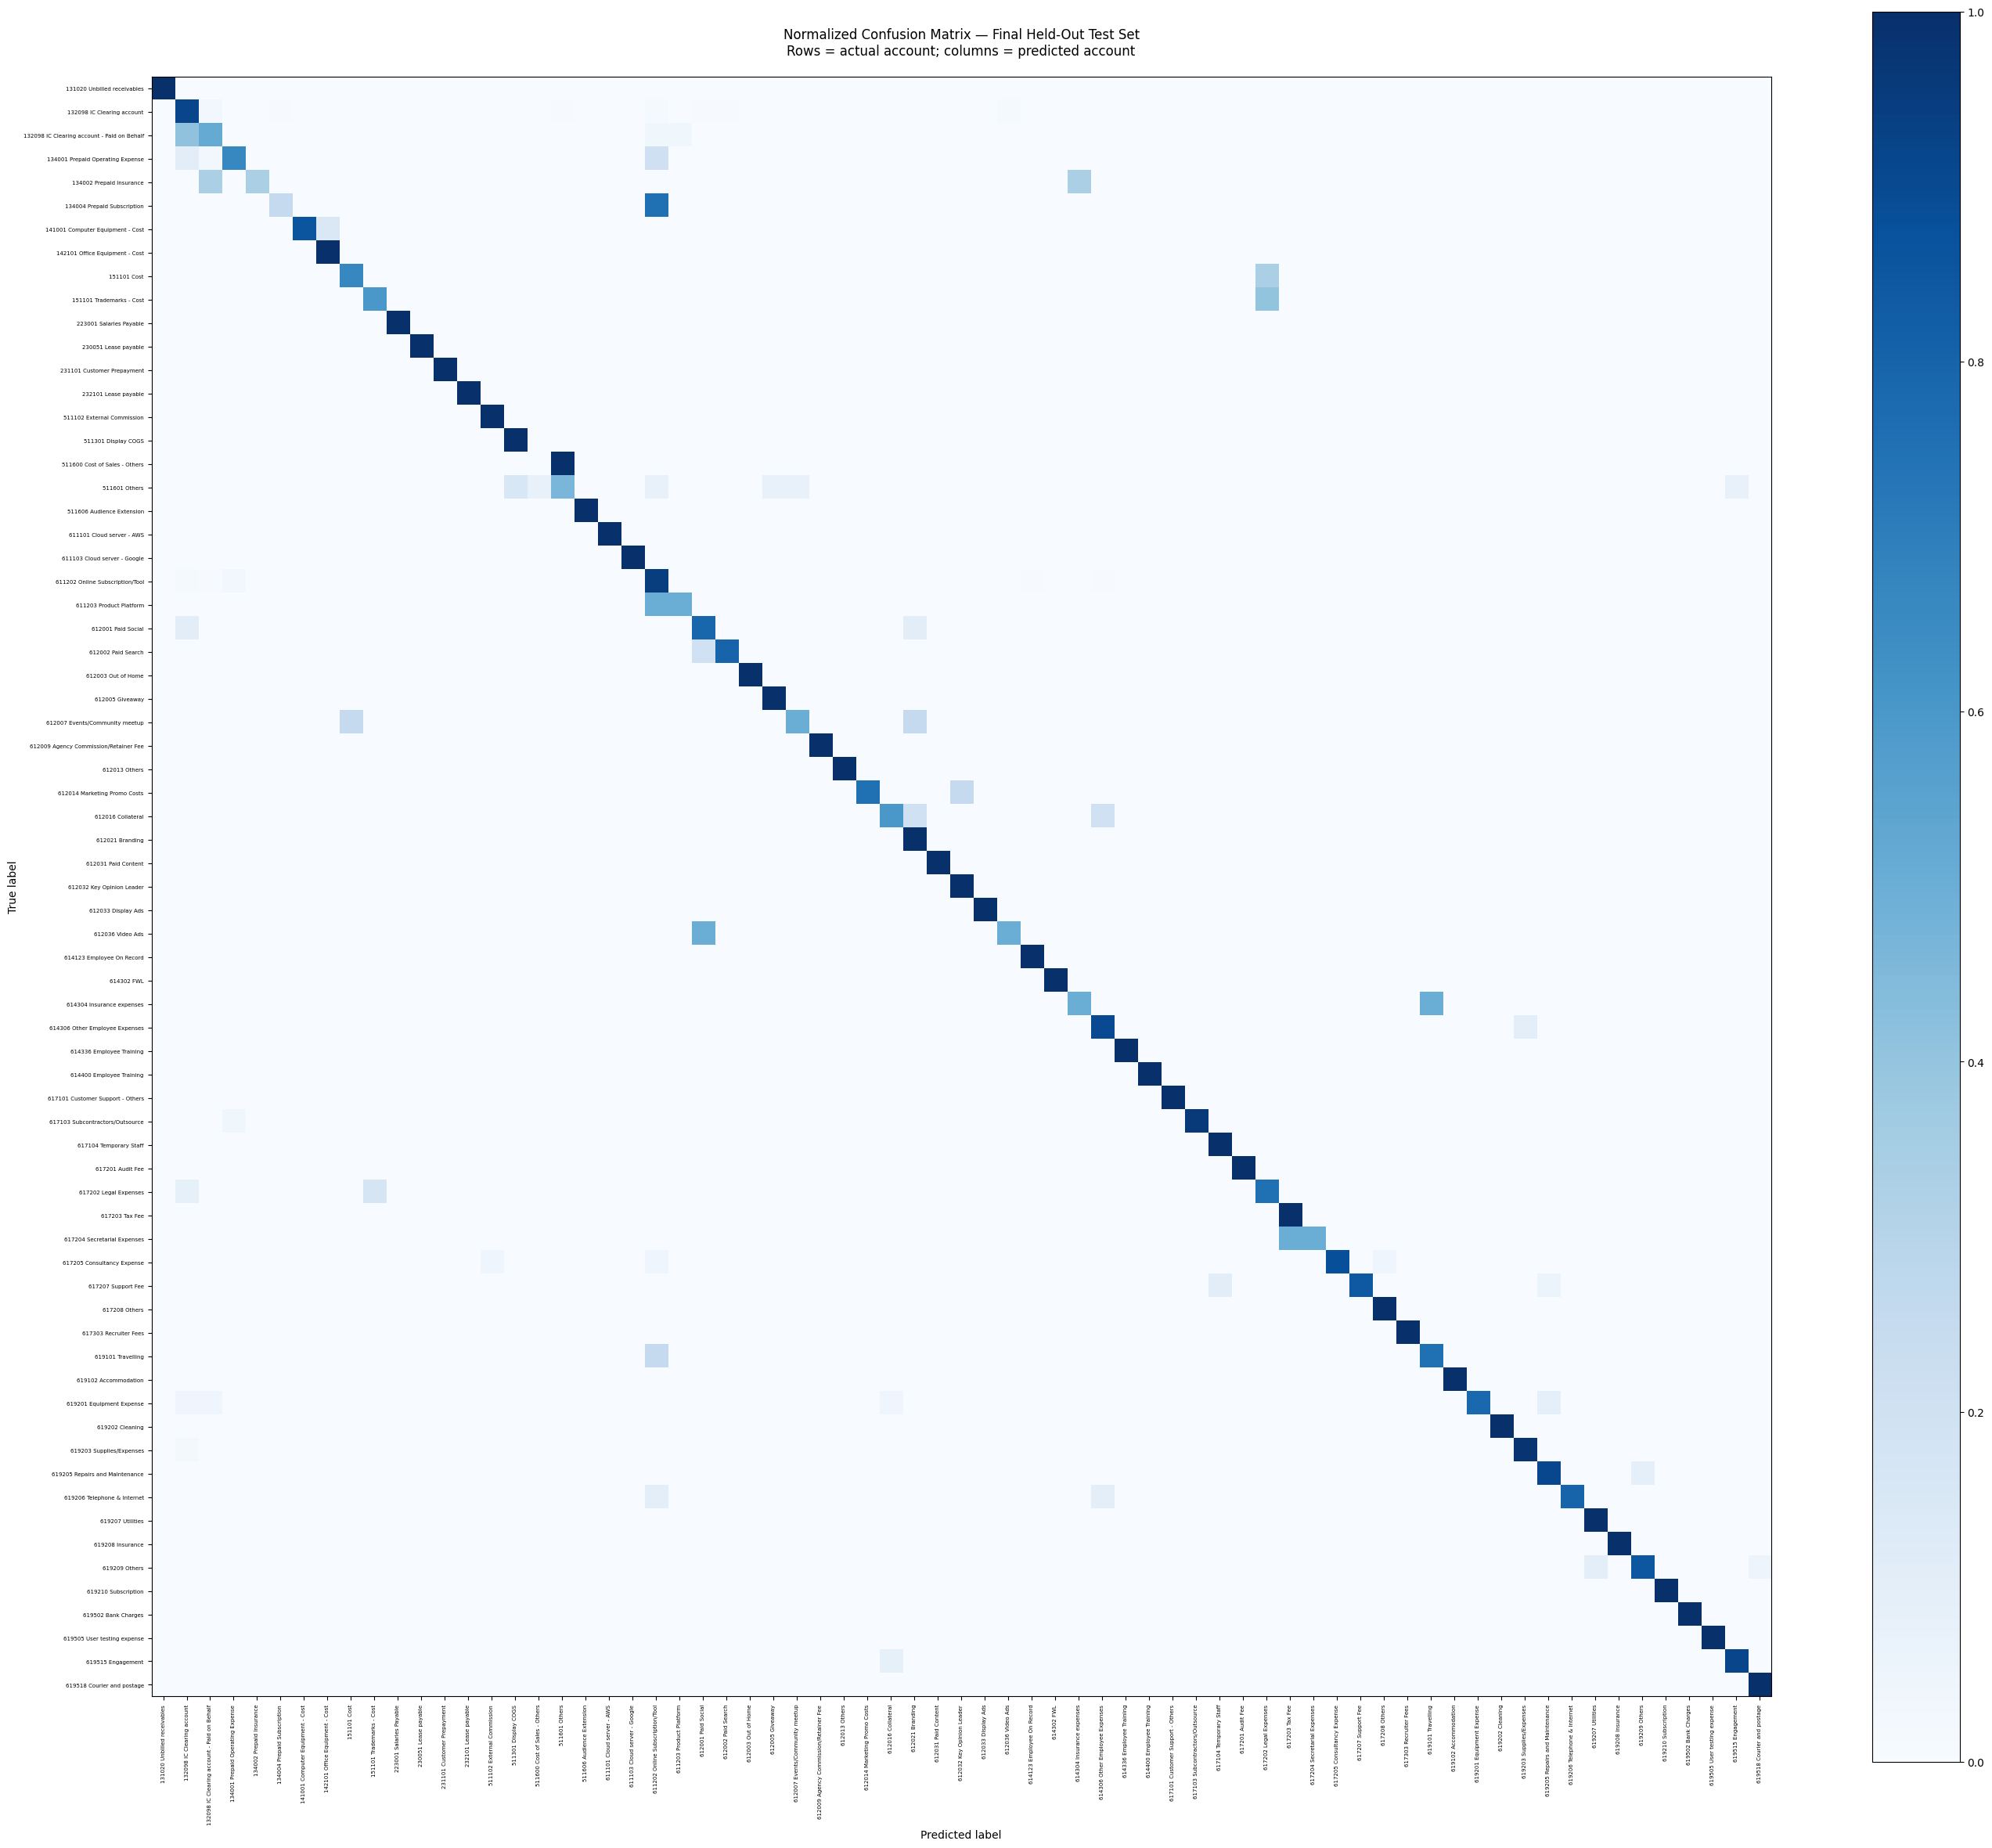

In [29]:
labels = le.classes_

cm = confusion_matrix(
    test_df["accountName"],
    test_pred,
    labels=labels,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(28, 24))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

display.plot(
    ax=ax,
    cmap="Blues",
    include_values=False,
    xticks_rotation=90,
    colorbar=True,
)

ax.set_title(
    "Normalized Confusion Matrix — Final Held-Out Test Set\n"
    "Rows = actual account; columns = predicted account",
    pad=20,
)
ax.tick_params(axis="both", labelsize=5)

plt.tight_layout()
plt.show()